In [38]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset, Dataset, random_split
from torchvision import transforms
import matplotlib.pyplot as plt
import numpy as np
import re
import datasets

In [39]:
class PairedImageDataset(Dataset):
    def __init__(self, lr_dataset, hr_dataset, transform_hr=None, transform_lr=None, image_key="image"):
        assert len(lr_dataset) == len(hr_dataset), "LR and HR datasets must have same length"
        self.lr_dataset = lr_dataset
        self.hr_dataset = hr_dataset
        self.transform_hr = transform_hr
        self.transform_lr = transform_lr
        self.image_key = image_key

    def __len__(self):
        return len(self.lr_dataset)

    def __getitem__(self, idx):
        X = self.hr_dataset[idx][self.image_key].convert("RGB")
        y = self.lr_dataset[idx][self.image_key].convert("RGB")
        
        X = self.transform_hr(X)
        y = self.transform_lr(y)

        return X, y

In [40]:
image_transform_hr = transforms.Compose([
    transforms.Resize((512, 512)),
    transforms.ToTensor(),
])
image_transform_lr = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
])

def build_urban100_pairs(raw_dataset, scale="2", hr_method="HR", lr_method="LR", image_key="image"):
    pattern = re.compile(r"img_(\d+)_SRF_(\d+)_(.+)\.png$")
    groups = {}

    for idx in range(len(raw_dataset)):
        image = raw_dataset[idx][image_key]
        filename = getattr(image, "filename", "") or ""
        match = pattern.search(filename)
        if match is None:
            continue

        image_id, image_scale, method = match.groups()
        if image_scale != scale:
            continue

        groups.setdefault(image_id, {})[method] = idx

    pairs = []
    skipped = []
    for image_id in sorted(groups, key=int):
        group = groups[image_id]
        if hr_method in group and lr_method in group:
            pairs.append((group[hr_method], group[lr_method]))
        else:
            skipped.append(image_id)

    return pairs, skipped

raw_dataset = datasets.load_dataset("Voxel51/Urban100", split="train")
pairs, skipped = build_urban100_pairs(raw_dataset, scale="2", hr_method="HR", lr_method="LR")
hr_indices = [hr_idx for hr_idx, lr_idx in pairs]
lr_indices = [lr_idx for hr_idx, lr_idx in pairs]

hr_dataset = Subset(raw_dataset, hr_indices)
lr_dataset = Subset(raw_dataset, lr_indices)
print(f"{len(raw_dataset)} raw rows -> {len(pairs)} HR/LR pairs; skipped={skipped}")
print(len(lr_dataset), len(hr_dataset))

batch_size=32
dataset = PairedImageDataset(lr_dataset, hr_dataset, transform_hr=image_transform_hr, transform_lr=image_transform_lr)
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
split_generator = torch.Generator().manual_seed(42)
train_dataset, val_dataset = random_split(dataset, [train_size, val_size], generator=split_generator)

train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
val_dataloader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=0)
print(f"train={len(train_dataset)} validation={len(val_dataset)}")

2201 raw rows -> 100 HR/LR pairs; skipped=[]
100 100
train=80 validation=20


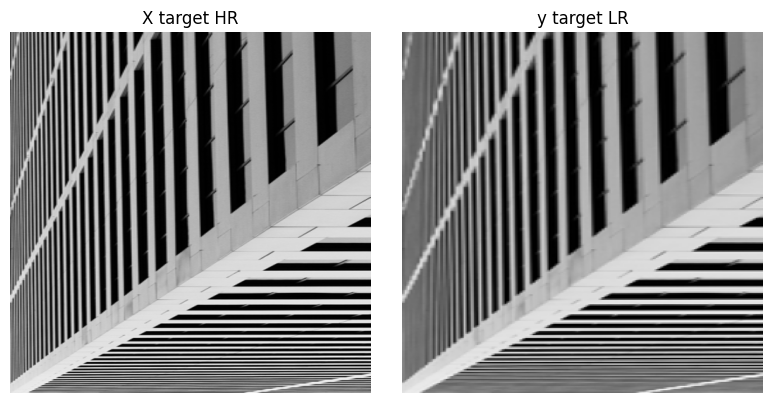

In [41]:
sample_idx = 10
X = image_transform_hr(hr_dataset[sample_idx]["image"].convert("RGB"))
y = image_transform_lr(lr_dataset[sample_idx]["image"].convert("RGB"))

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
for ax, image, title in zip(axes, (X, y), ("X target HR", "y target LR")):
    ax.imshow(image.permute(1, 2, 0).clamp(0, 1))
    ax.set_title(title)
    ax.axis("off")

fig.tight_layout()
plt.show()

In [42]:
class ResidualBlock(nn.Module):
    def __init__(self, c_in: int = 16, c_out: int = 16):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(c_in, c_out, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(c_out, c_out, kernel_size=3, padding=1),
        )
        self.skip = nn.Identity() if c_in == c_out else nn.Conv2d(c_in, c_out, kernel_size=1)
        self.relu = nn.ReLU(inplace=True)

    def forward(self, X):
        return self.relu(self.block(X) + self.skip(X))

In [43]:
class Downscaler(nn.Module):
    def __init__(self, c_in: int = 3, n_residual_blocks: int = 3):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(c_in, 12, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(12, 16, kernel_size=3, stride=2, padding=1),
            nn.ReLU(inplace=True),
        )
        self.res_blocks = nn.Sequential(*[
            ResidualBlock(c_in=16, c_out=16) for _ in range(n_residual_blocks)
        ])
        self.lr_head = nn.Conv2d(16, c_in, kernel_size=1)
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(c_in, 8, kernel_size=4, stride=2, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(8, c_in, kernel_size=3, padding=1),
        )


    def forward(self, X):
        encoded = self.encoder(X)
        features_lr = self.res_blocks(encoded)
        pred_lr = self.lr_head(features_lr)
        pred_hr = self.decoder(pred_lr)
        return pred_lr, pred_hr

In [44]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"using device {device}")

using device cuda


In [45]:
def rgb_to_yuv(rgb):
    r, g, b = rgb[:, 0:1], rgb[:, 1:2], rgb[:, 2:3]
    y = 0.299 * r + 0.587 * g + 0.114 * b
    u = -0.14713 * r - 0.28886 * g + 0.436 * b
    v = 0.615 * r - 0.51499 * g - 0.10001 * b
    return torch.cat((y, u, v), dim=1)

def yuv_to_rgb(yuv):
    y, u, v = yuv[:, 0:1], yuv[:, 1:2], yuv[:, 2:3]
    r = y + 1.13983 * v
    g = y - 0.39465 * u - 0.58060 * v
    b = y + 2.03211 * u
    return torch.cat((r, g, b), dim=1)

In [46]:
model = Downscaler(c_in=1, n_residual_blocks=10).to(device)

In [47]:
upscale_mode = "bicubic"
lr_loss_weight = 1.0
hr_loss_weight = 1.0

def mse(pred, target):
    return (pred - target).square().mean()

initial_lr = 0.001
validation_interval = 5

def evaluate_luma(model, dataloader):
    losses = []
    lr_losses = []
    hr_losses = []
    hr_baseline_losses = []
    hr_improvements = []

    model.eval()
    with torch.no_grad():
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)
            X_yuv = rgb_to_yuv(X)
            y_yuv = rgb_to_yuv(y)
            X_luma = X_yuv[:, 0:1]
            y_luma = y_yuv[:, 0:1]

            pred_lr_luma, pred_hr_luma = model(X_luma)
            lr_loss = mse(pred_lr_luma, y_luma)
            hr_loss = mse(pred_hr_luma, X_luma)
            loss = lr_loss_weight * lr_loss + hr_loss_weight * hr_loss

            y_luma_up = F.interpolate(y_luma, size=X_luma.shape[-2:], mode=upscale_mode, align_corners=False)
            hr_baseline_loss = mse(y_luma_up, X_luma)

            losses.append(loss.item())
            lr_losses.append(lr_loss.item())
            hr_losses.append(hr_loss.item())
            hr_baseline_loss = hr_baseline_loss.item()
            hr_baseline_losses.append(hr_baseline_loss)
            hr_improvements.append(hr_baseline_loss - hr_loss.item())

    return {
        "loss": np.mean(losses),
        "lr_loss": np.mean(lr_losses),
        "hr_loss": np.mean(hr_losses),
        "hr_baseline_loss": np.mean(hr_baseline_losses),
        "hr_improvement": np.mean(hr_improvements),
    }

loss_hist = []
val_loss_hist = []
optim = torch.optim.AdamW(model.parameters(), lr=initial_lr)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optim,
    mode="min",
    factor=0.5,
    patience=2,
    min_lr=0.00003,
)

for epoch in range(100):
    losses = []
    lr_losses = []
    hr_losses = []
    hr_baseline_losses = []
    hr_improvements = []

    model.train()
    for X, y in train_dataloader:
        X, y = X.to(device), y.to(device)
        X_yuv = rgb_to_yuv(X)
        y_yuv = rgb_to_yuv(y)
        X_luma = X_yuv[:, 0:1]
        y_luma = y_yuv[:, 0:1]
        optim.zero_grad()

        pred_lr_luma, pred_hr_luma = model(X_luma)
        lr_loss = mse(pred_lr_luma, y_luma)
        hr_loss = mse(pred_hr_luma, X_luma)

        loss = lr_loss_weight * lr_loss + hr_loss_weight * hr_loss

        loss.backward()
        optim.step()

        with torch.no_grad():
            y_luma_up = F.interpolate(y_luma, size=X_luma.shape[-2:], mode=upscale_mode, align_corners=False)
            hr_baseline_loss = mse(y_luma_up, X_luma)

        losses.append(loss.item())
        lr_losses.append(lr_loss.item())
        hr_losses.append(hr_loss.item())
        hr_baseline_loss = hr_baseline_loss.item()
        hr_baseline_losses.append(hr_baseline_loss)
        hr_improvements.append(hr_baseline_loss - hr_loss.item())

    loss = np.mean(losses)
    lr_loss = np.mean(lr_losses)
    hr_loss = np.mean(hr_losses)
    hr_baseline_loss = np.mean(hr_baseline_losses)
    hr_improvement = np.mean(hr_improvements)

    loss_hist.append(loss)
    current_lr = optim.param_groups[0]["lr"]
    print(
        f"epoch {epoch}: luma_loss={loss:.6f} lr_luma_loss={lr_loss:.6f} "
        f"hr_luma_loss={hr_loss:.6f} hr_luma_baseline={hr_baseline_loss:.6f} "
        f"hr_luma_improvement={hr_improvement:.6f} lr={current_lr:.6g} "
    )

    if epoch == 0 or (epoch + 1) % validation_interval == 0:
        val_metrics = evaluate_luma(model, val_dataloader)
        val_loss_hist.append((epoch, val_metrics["loss"]))
        print(
            f"validation epoch {epoch}: luma_loss={val_metrics['loss']:.6f} "
            f"lr_luma_loss={val_metrics['lr_loss']:.6f} "
            f"hr_luma_loss={val_metrics['hr_loss']:.6f} "
            f"hr_luma_baseline={val_metrics['hr_baseline_loss']:.6f} "
            f"hr_luma_improvement={val_metrics['hr_improvement']:.6f}"
        )
        scheduler.step(val_metrics["loss"])


epoch 0: luma_loss=0.382146 lr_luma_loss=0.147198 hr_luma_loss=0.234948 hr_luma_baseline=0.002922 hr_luma_improvement=-0.232026 lr=0.001 
validation epoch 0: luma_loss=0.341995 lr_luma_loss=0.086928 hr_luma_loss=0.255067 hr_luma_baseline=0.002746 hr_luma_improvement=-0.252321
epoch 1: luma_loss=0.277573 lr_luma_loss=0.055977 hr_luma_loss=0.221596 hr_luma_baseline=0.002806 hr_luma_improvement=-0.218790 lr=0.001 
epoch 2: luma_loss=0.240669 lr_luma_loss=0.024909 hr_luma_loss=0.215760 hr_luma_baseline=0.002868 hr_luma_improvement=-0.212892 lr=0.001 
epoch 3: luma_loss=0.207100 lr_luma_loss=0.015925 hr_luma_loss=0.191175 hr_luma_baseline=0.002793 hr_luma_improvement=-0.188382 lr=0.001 
epoch 4: luma_loss=0.185008 lr_luma_loss=0.018056 hr_luma_loss=0.166951 hr_luma_baseline=0.002832 hr_luma_improvement=-0.164119 lr=0.001 
validation epoch 4: luma_loss=0.198081 lr_luma_loss=0.006741 hr_luma_loss=0.191340 hr_luma_baseline=0.002746 hr_luma_improvement=-0.188594
epoch 5: luma_loss=0.168821 lr_l

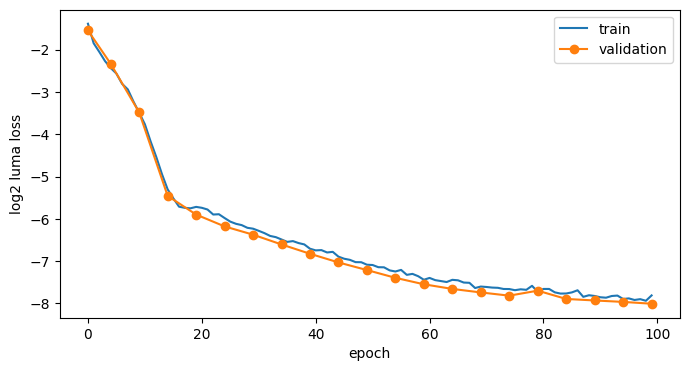

In [48]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(np.log2(loss_hist), label="train")
if val_loss_hist:
    val_epochs, val_losses = zip(*val_loss_hist)
    ax.plot(val_epochs, np.log2(val_losses), marker="o", label="validation")
ax.set_xlabel("epoch")
ax.set_ylabel("log2 luma loss")
ax.legend()
plt.show()

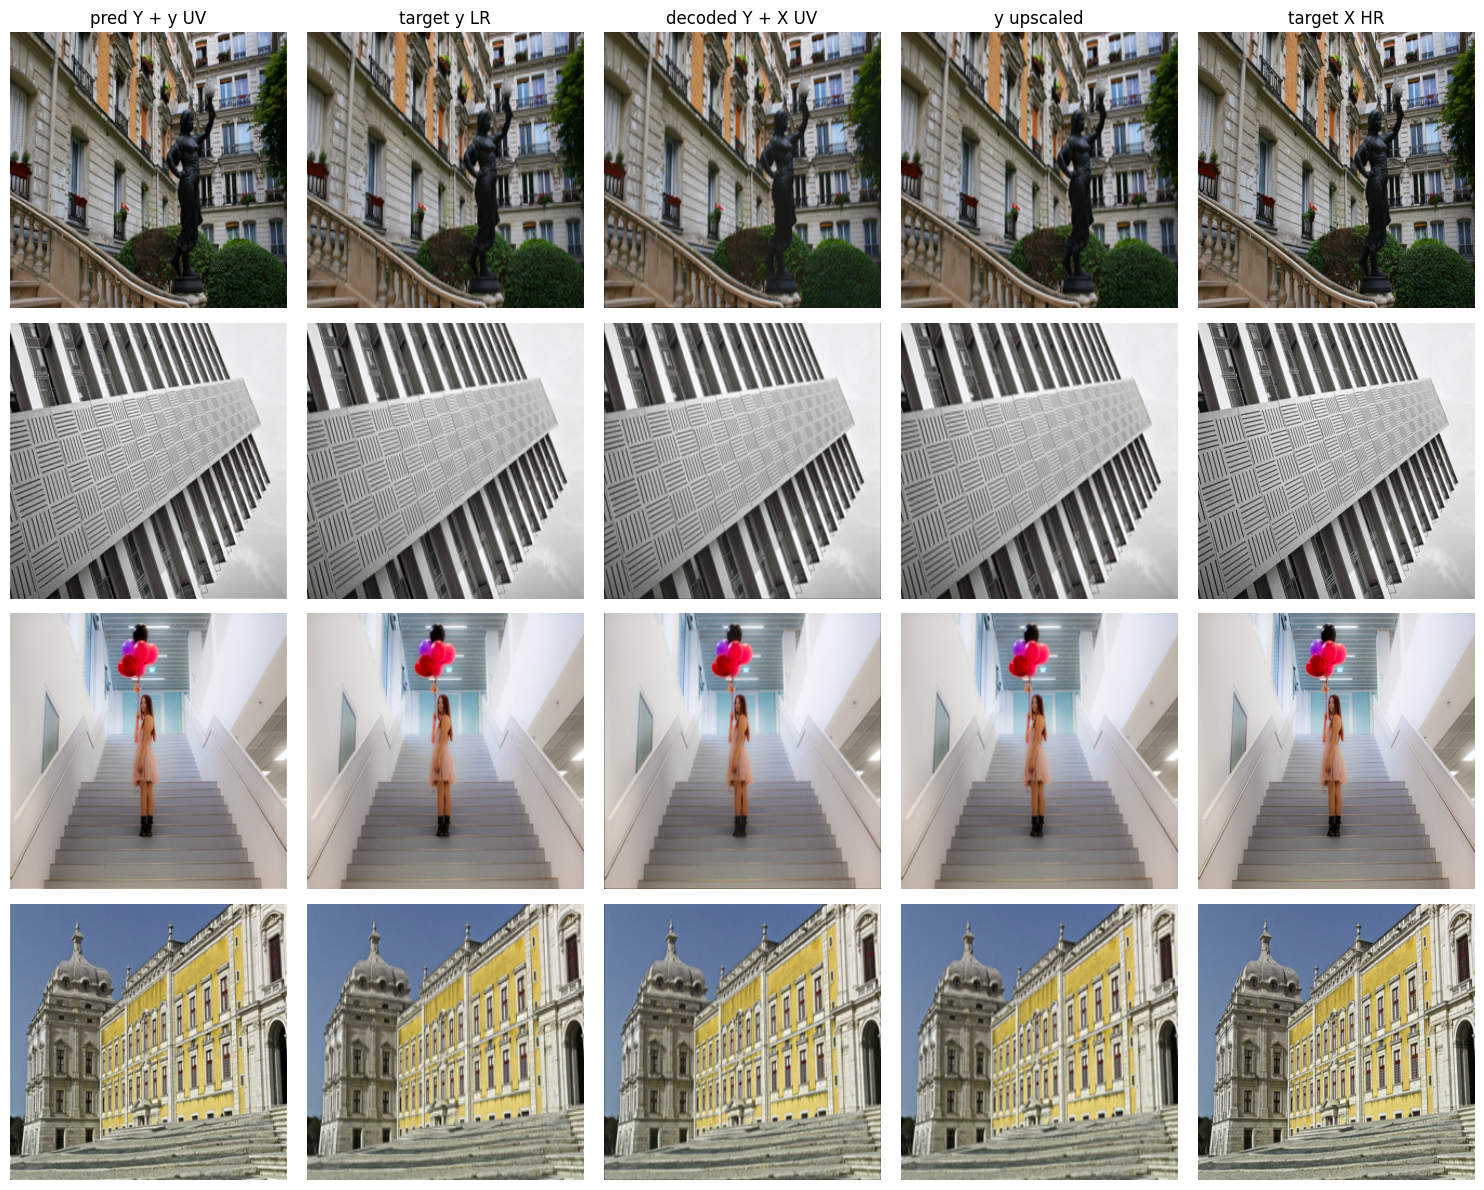

In [49]:
model.eval()
with torch.no_grad():
    X, y = next(iter(val_dataloader))
    X, y = X.to(device), y.to(device)
    X_yuv = rgb_to_yuv(X)
    y_yuv = rgb_to_yuv(y)
    pred_lr_luma, pred_hr_luma = model(X_yuv[:, 0:1])
    pred_lr_yuv = torch.cat((pred_lr_luma, y_yuv[:, 1:3]), dim=1)
    pred_hr_yuv = torch.cat((pred_hr_luma, X_yuv[:, 1:3]), dim=1)
    pred_lr = yuv_to_rgb(pred_lr_yuv)
    pred_hr = yuv_to_rgb(pred_hr_yuv)
    y_up = F.interpolate(y, size=X.shape[-2:], mode=upscale_mode, align_corners=False)

sample_count = min(4, X.shape[0])
columns = [
    ("pred Y + y UV", pred_lr),
    ("target y LR", y),
    ("decoded Y + X UV", pred_hr),
    ("y upscaled", y_up),
    ("target X HR", X),
]
fig, axes = plt.subplots(sample_count, len(columns), figsize=(3 * len(columns), 3 * sample_count))
if sample_count == 1:
    axes = axes[None, :]

for row in range(sample_count):
    for col, (title, images) in enumerate(columns):
        ax = axes[row, col]
        image = images[row].detach().cpu().clamp(0, 1).permute(1, 2, 0)
        ax.imshow(image)
        ax.axis("off")
        if row == 0:
            ax.set_title(title)
        if col == 0:
            ax.set_ylabel(f"sample {row}", rotation=0, labelpad=35, va="center")

fig.tight_layout()
plt.show()


In [50]:
torch.save(model.state_dict(), "model.pth")